In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [4]:
# loading database connection
conn = sqlite3.connect("inventory.db")

# fetching vendor summary data
df = pd.read_sql("SELECT * FROM vendor_sales_summary ", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesQuantity,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,5101919.51,142049.0,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,4819073.49,160247.0,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,4538120.60,187140.0,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,4475972.88,200412.0,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,4223107.62,135838.0,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [10]:
pd.read_sql("SELECT COUNT(*) FROM vendor_sales_summary", conn)

,COUNT(*)
0,10692


In [12]:
# summary statatics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


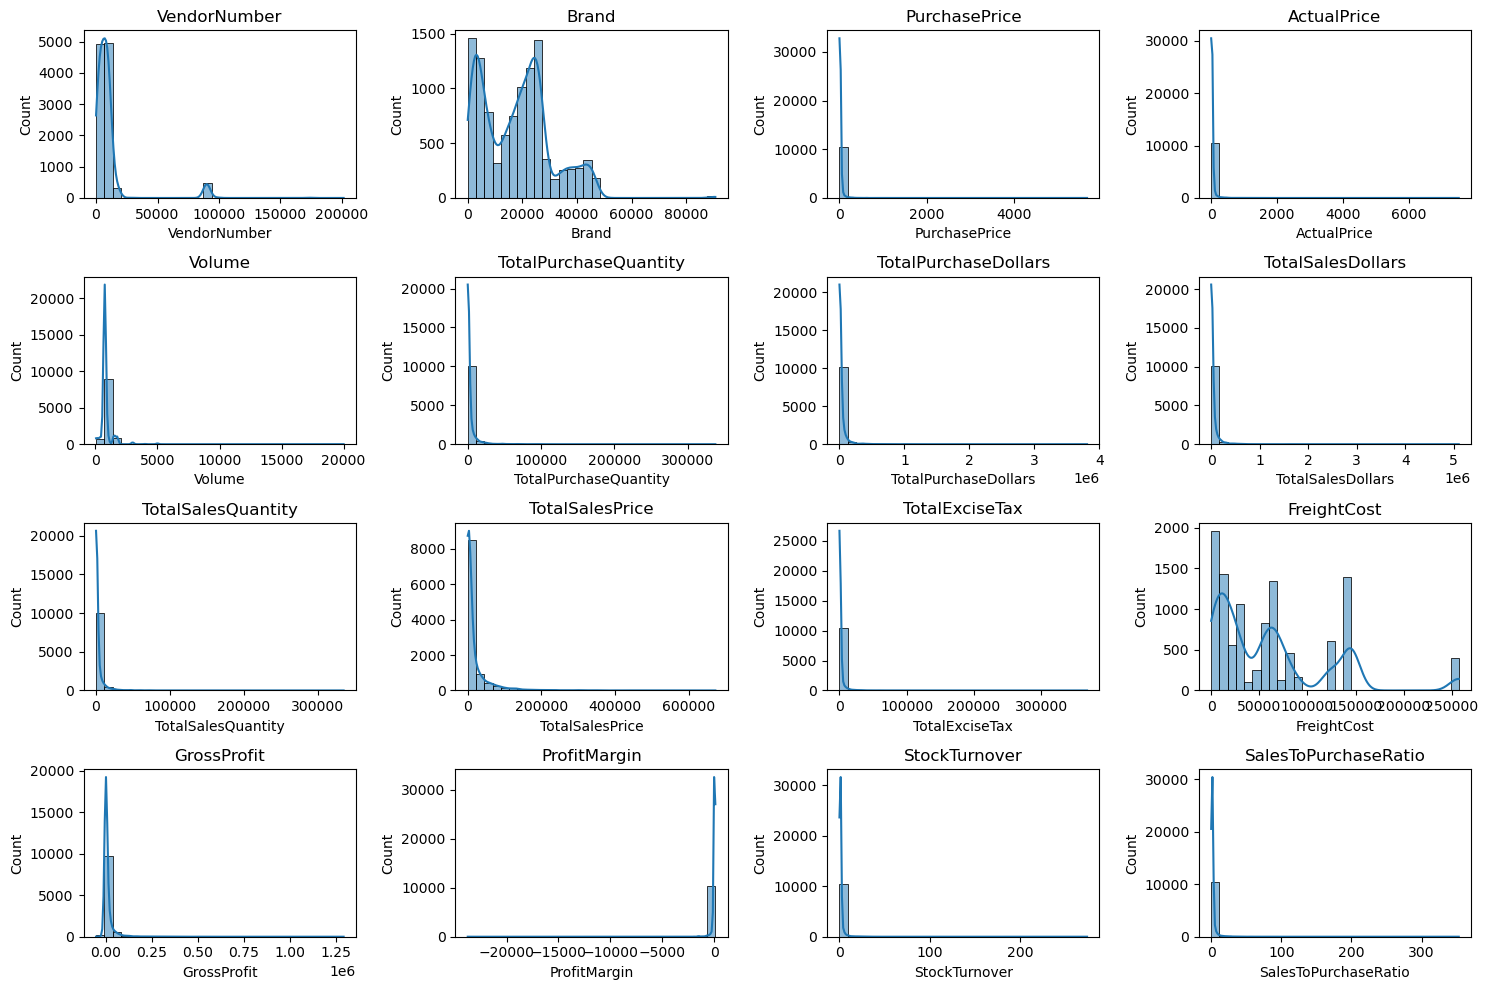

In [5]:
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize =(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde = True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

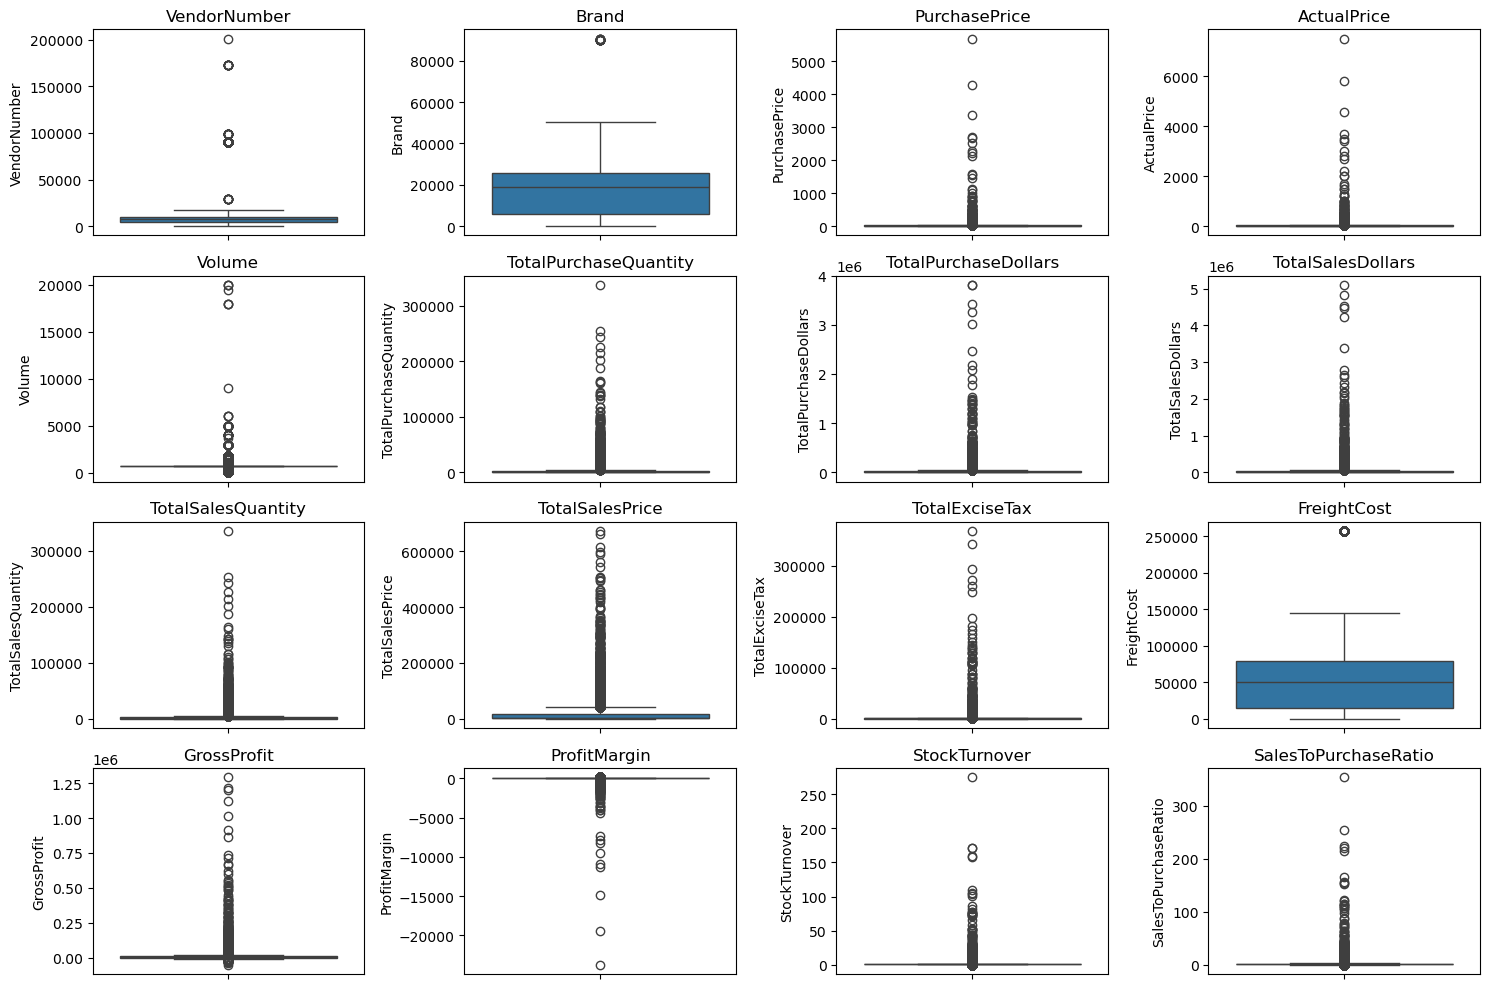

In [6]:
plt.figure(figsize =(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [24]:
df= pd.read_sql_query("""select * from vendor_sales_summary 
where GrossProfit = 0 
and ProfitMargin > 0 
and TotalSalesQuantity > 0
""",conn)

In [27]:
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesQuantity,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio


In [28]:
len(df)

0

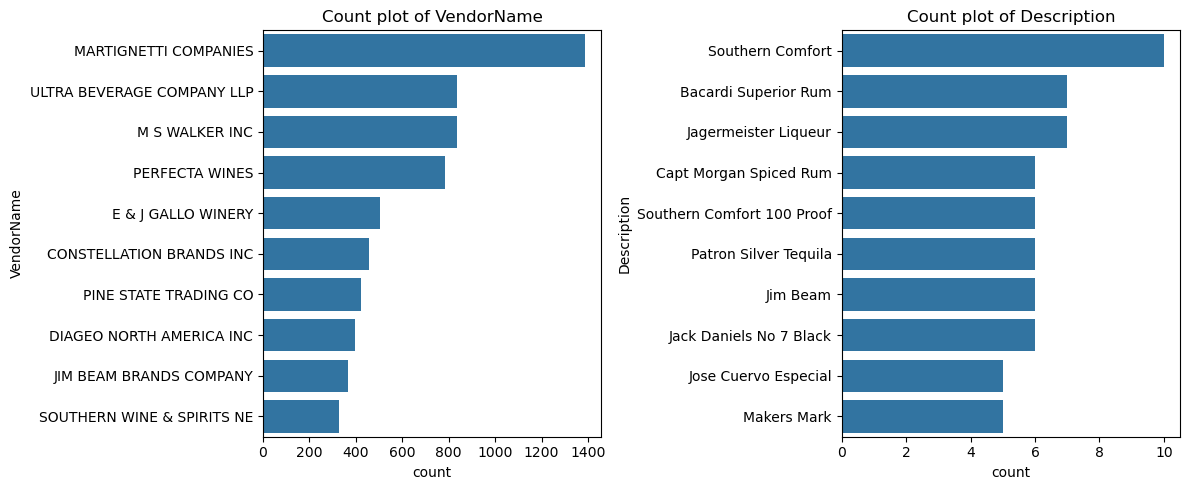

In [7]:
categorial_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(categorial_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])
    plt.title(f"Count plot of {col}")

plt.tight_layout()
plt.show()

In [10]:
print(df["VendorName"].nunique())
print(df["Description"].nunique())

128
9651


Description
Jack Daniels No 7 Black    1
Tito's Handmade Vodka      1
Absolut 80 Proof           1
Capt Morgan Spiced Rum     1
Ketel One Vodka            1
Name: count, dtype: int64

In [11]:
print(len(df))

10692


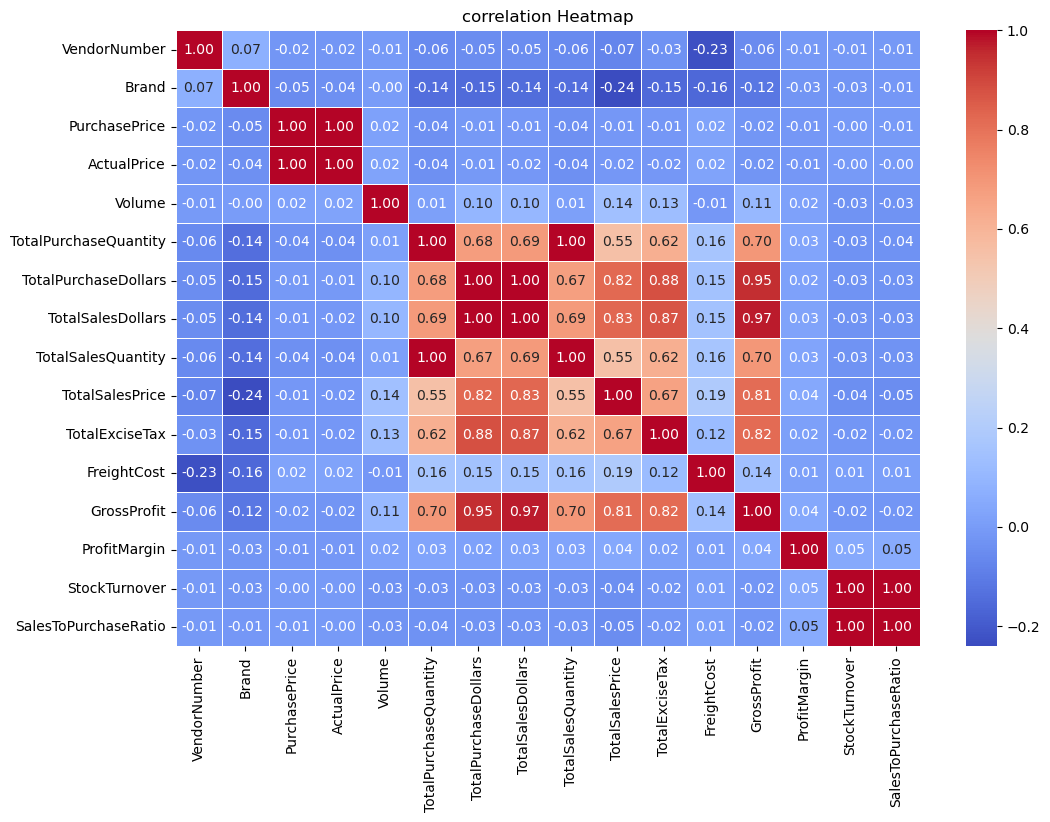

In [8]:
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",linewidths=0.5)
plt.title("correlation Heatmap")
plt.show()

In [ ]:
# data analysis
# identify Brand that need promotional or pricing adjustments which exhibit lower sales performance but higer profit margins

In [9]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'
}).reset_index()

In [10]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.75)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.25)

In [11]:
low_sales_threshold

np.float64(25762.690000000002)

In [12]:
high_margin_threshold

np.float64(10.697559409512351)

In [13]:
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("brand with low sales but high profit margins:")
display(target_brands.sort_values('TotalSalesDollars'))

brand with low sales but high profit margins:


,Description,TotalSalesDollars,ProfitMargin
8676,Terruzzi & Puthod Vernaccia,4.99,32.464930
3588,Firefly Ridge Chard,5.79,31.088083
181,Albero Sparkling Wh Organic,5.79,28.497409
8134,Smirnoff Light Strawberry,5.94,50.168350
224,Allen's Blue Curacao Liqueur,5.99,20.033389
...,...,...,...
5526,Linie Aquavit,25642.88,27.566609
4281,Hardys Shiraz Ausl,25643.13,39.140893
5933,Matanzas Creek Svgn Bl Sonom,25680.52,24.519636
7522,Robert Hall Cab Svgn,25727.61,83.867992


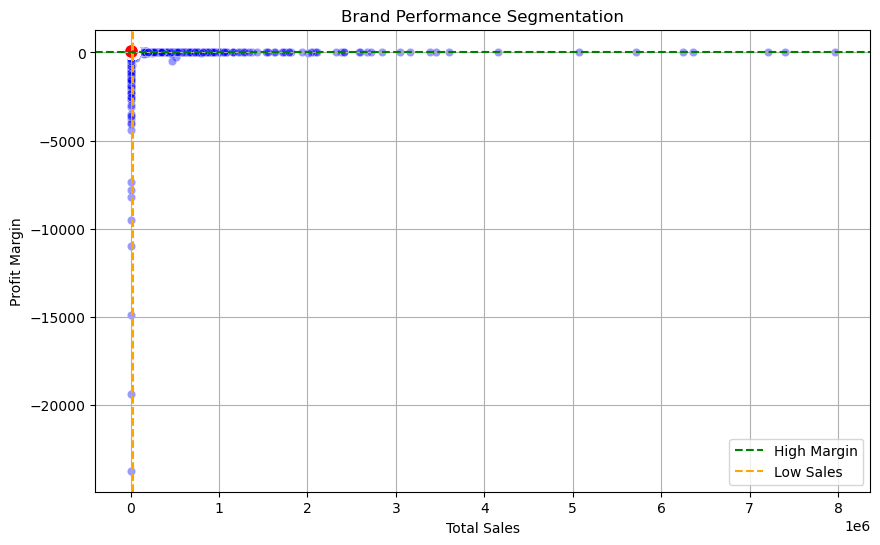

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    alpha=0.4,
    color="blue"
)

sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color="red",
    s=100
)

plt.axhline(high_margin_threshold, linestyle='--', color='green', label="High Margin")
plt.axvline(low_sales_threshold, linestyle='--', color='orange', label="Low Sales")

plt.xlabel("Total Sales")
plt.ylabel("Profit Margin")
plt.title("Brand Performance Segmentation")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<1000]

In [17]:
sales_threshold = brand_performance['TotalSalesDollars'].median()
margin_threshold = brand_performance['ProfitMargin'].median()

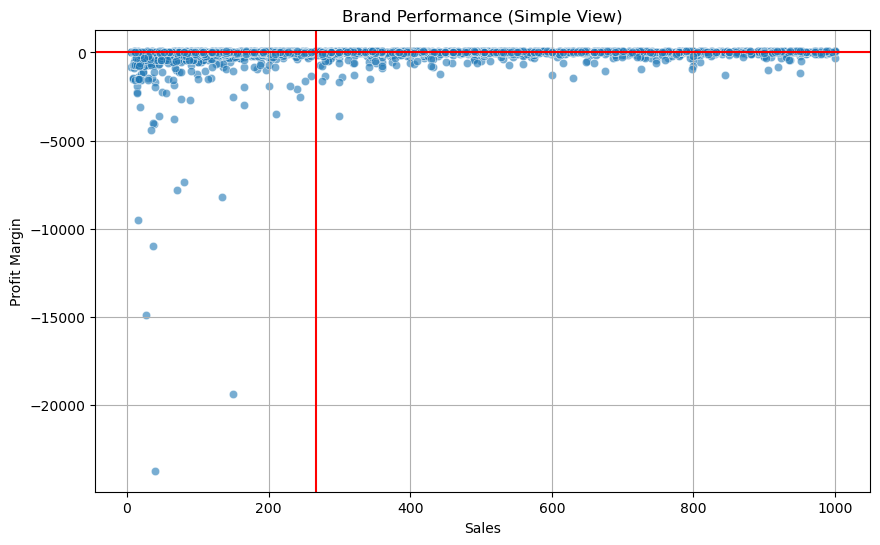

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    alpha=0.6
)

plt.axvline(sales_threshold, color='red')
plt.axhline(margin_threshold, color='red')

plt.xlabel("Sales")
plt.ylabel("Profit Margin")
plt.title("Brand Performance (Simple View)")
plt.grid(True)
plt.show()

In [19]:
def format_dollars(value):
    if value >= 1_000_000:
        return f" {value / 1_000_000:.2f} M"
    elif value >= 1_000:
        return f" {value / 1_000:.2f}K"
    else:
        return str(value)

In [20]:
#Top Vendors & Brands by Sales Performance

top_vendors = df.groupby("VendorName") ["TotalSalesDollars"].sum().nlargest (10)
top_brands= df.groupby("Description") ["TotalSalesDollars"].sum().nlargest (10)

top_vendors

VendorName
DIAGEO NORTH AMERICA INC      68739834.97
MARTIGNETTI COMPANIES         40960117.82
PERNOD RICARD USA             32279544.17
JIM BEAM BRANDS COMPANY       31898621.16
BACARDI USA INC               25005365.79
CONSTELLATION BRANDS INC      24467134.23
E & J GALLO WINERY            18553774.66
BROWN-FORMAN CORP             18476611.60
ULTRA BEVERAGE COMPANY LLP    17802646.10
M S WALKER INC                15436066.26
Name: TotalSalesDollars, dtype: float64

In [21]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black     7.96 M
Tito's Handmade Vodka       7.40 M
Grey Goose Vodka            7.21 M
Capt Morgan Spiced Rum      6.36 M
Absolut 80 Proof            6.24 M
Jameson Irish Whiskey       5.72 M
Ketel One Vodka             5.07 M
Baileys Irish Cream         4.15 M
Kahlua                      3.60 M
Tanqueray                   3.46 M
Name: TotalSalesDollars, dtype: object

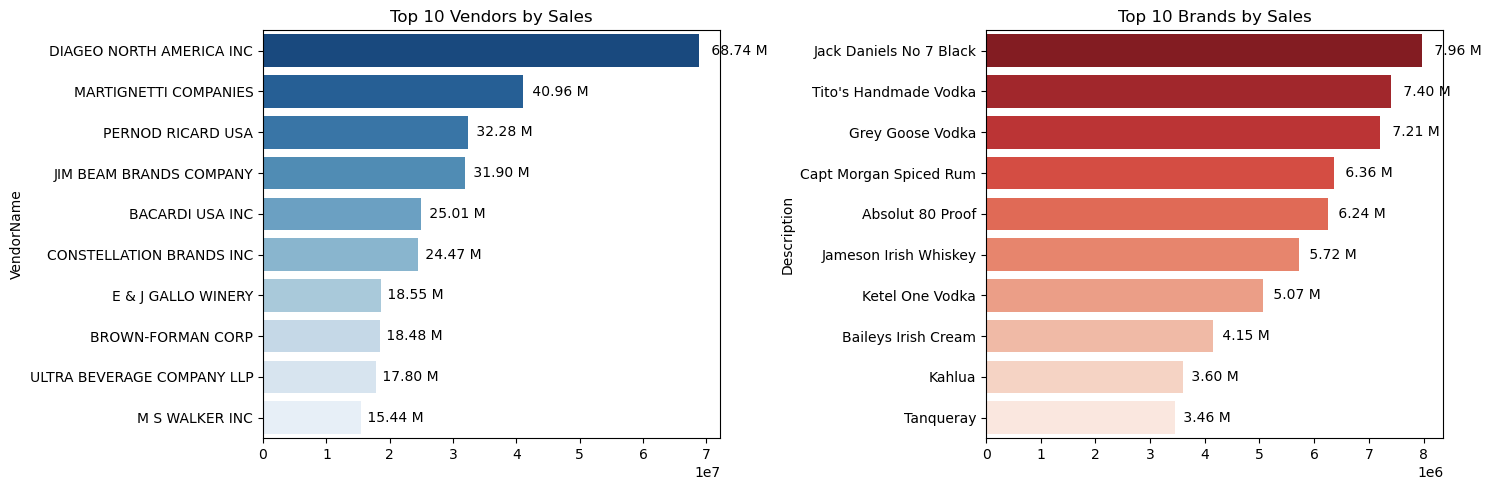

In [22]:
plt.figure(figsize=(15,5))

#Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02), 
            bar.get_y() + bar.get_height() / 2,
            format_dollars(bar.get_width()),
            ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r") 
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

In [34]:
# which vendors contribute the most to total purchases dollars

In [27]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance.shape
    

(128, 4)

In [28]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum() 

In [33]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending=False),2)

In [34]:
# Display Top 10 Vendors

top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors ['TotalSalesDollars'].apply(format_dollars)
top_vendors ['TotalPurchaseDollars'] = top_vendors ['TotalPurchaseDollars'].apply(format_dollars)
top_vendors ['GrossProfit'] = top_vendors ['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
28,DIAGEO NORTH AMERICA INC,50.96 M,17.78 M,68.74 M,0.16
63,MARTIGNETTI COMPANIES,27.86 M,13.10 M,40.96 M,0.09
50,JIM BEAM BRANDS COMPANY,24.20 M,7.70 M,31.90 M,0.08
74,PERNOD RICARD USA,24.12 M,8.16 M,32.28 M,0.07
8,BACARDI USA INC,17.62 M,7.38 M,25.01 M,0.05
23,CONSTELLATION BRANDS INC,15.57 M,8.89 M,24.47 M,0.05
14,BROWN-FORMAN CORP,13.53 M,4.95 M,18.48 M,0.04
114,ULTRA BEVERAGE COMPANY LLP,13.21 M,4.59 M,17.80 M,0.04
33,E & J GALLO WINERY,12.29 M,6.26 M,18.55 M,0.04
59,M S WALKER INC,10.94 M,4.50 M,15.44 M,0.03


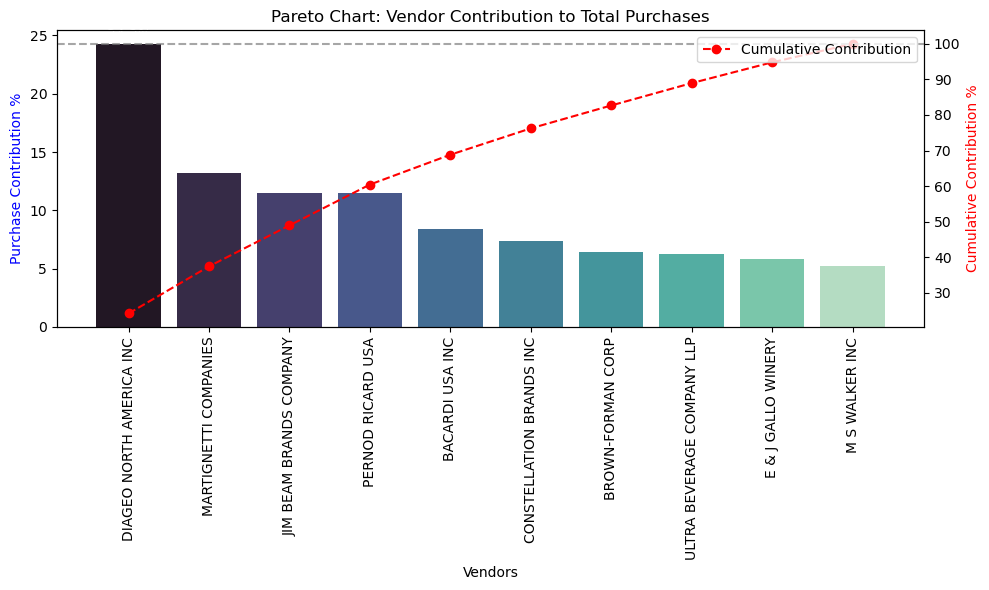

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(10, 6))

# -------------------------
# Bar plot (Purchase Contribution %)
# -------------------------
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContribution%'],
    palette="mako",
    ax=ax1
)

# Value labels
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha='center',
        fontsize=10,
        color='white'
    )

# -------------------------
# Line plot (Cumulative %)
# -------------------------
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution'
)

# -------------------------
# Labels & formatting
# -------------------------
ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)

ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)

ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [35]:
print(top_vendors.columns)


Index(['VendorName', 'TotalPurchaseDollars', 'GrossProfit',
       'TotalSalesDollars', 'PurchaseContribution%'],
      dtype='object')


In [36]:
top_vendors = top_vendors.sort_values('PurchaseContribution%', ascending=False)

In [37]:
top_vendors['Cumulative_Contribution'] = top_vendors['PurchaseContribution%'].cumsum()

In [36]:
top_vendors['Cumulative_Contribution'] = top_vendors['PurchaseContribution%'].cumsum()

In [38]:
ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution'
)

In [102]:
top_vendors = top_vendors.head(10)

In [39]:
print(top_vendors.head())
print(top_vendors.dtypes)

                  VendorName TotalPurchaseDollars GrossProfit  \
28  DIAGEO NORTH AMERICA INC              50.96 M     17.78 M   
63     MARTIGNETTI COMPANIES              27.86 M     13.10 M   
50   JIM BEAM BRANDS COMPANY              24.20 M      7.70 M   
74         PERNOD RICARD USA              24.12 M      8.16 M   
8            BACARDI USA INC              17.62 M      7.38 M   

   TotalSalesDollars  PurchaseContribution%  Cumulative_Contribution  
28           68.74 M                   0.16                     0.16  
63           40.96 M                   0.09                     0.25  
50           31.90 M                   0.08                     0.33  
74           32.28 M                   0.07                     0.40  
8            25.01 M                   0.05                     0.45  
VendorName                  object
TotalPurchaseDollars        object
GrossProfit                 object
TotalSalesDollars           object
PurchaseContribution%      float64
Cumulati

In [40]:
def convert_million(x):
    if isinstance(x, str):
        return float(x.replace('M', '').strip()) * 1_000_000
    return x

In [41]:
df['TotalPurchaseDollars'] = df['TotalPurchaseDollars'].apply(convert_million)
df['GrossProfit'] = df['GrossProfit'].apply(convert_million)
df['TotalSalesDollars'] = df['TotalSalesDollars'].apply(convert_million)

In [42]:
df['PurchaseContribution%'] = (
    df['TotalPurchaseDollars'] / df['TotalPurchaseDollars'].sum()
) * 100

In [43]:
top_vendors = df.groupby('VendorName', as_index=False)['TotalPurchaseDollars'].sum()

In [44]:
top_vendors = top_vendors.sort_values('TotalPurchaseDollars', ascending=False).head(10)

top_vendors['PurchaseContribution%'] = (
    top_vendors['TotalPurchaseDollars'] / top_vendors['TotalPurchaseDollars'].sum()
) * 100

top_vendors['Cumulative_Contribution'] = top_vendors['PurchaseContribution%'].cumsum()

In [104]:
# how much of procurement is dependent on the top vendors

In [107]:
print(f" Total purchases contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

 Total purchases contribution of top 10 vendors is 100.0 %


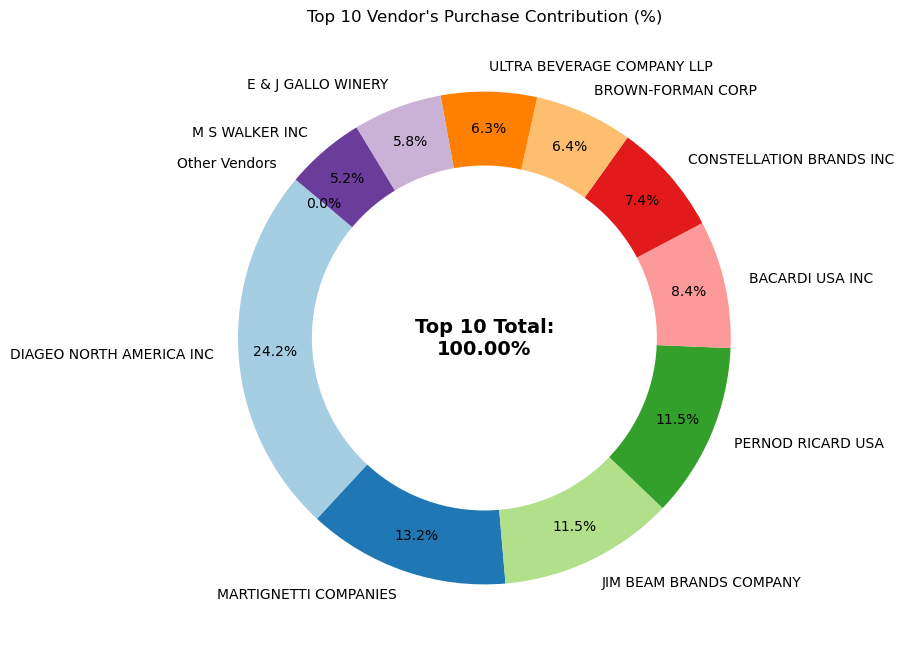

In [47]:
vendors = list(top_vendors['VendorName'].values)

purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors"
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# White center circle (donut effect)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Center text (FIXED)
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

In [49]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [50]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3 , labels=["Small","Medium","Large"])

In [51]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
10687,Small,2
10688,Small,6
10689,Small,2
10690,Small,1


In [52]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,43.776954
Medium,17.894005
Large,11.308807


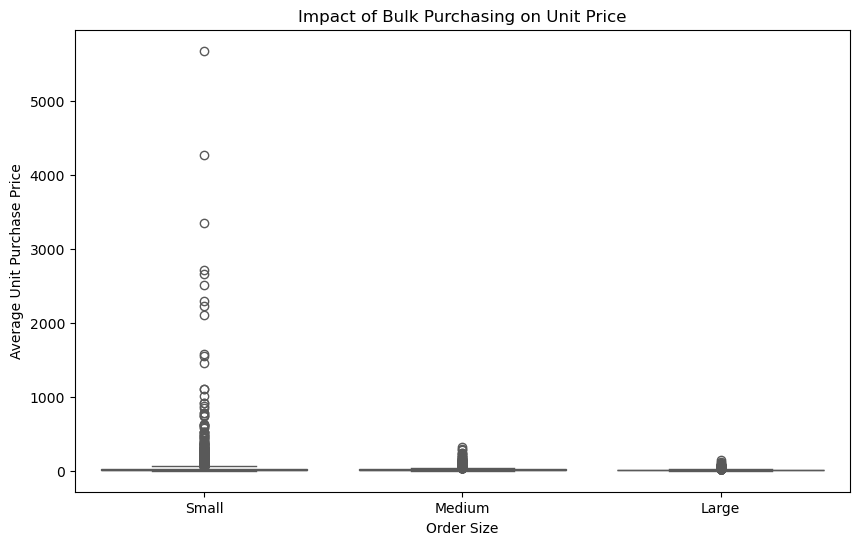

In [53]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

In [126]:
# which vendors have low inventory turnover, indicating excess stock and slow-moving products

In [54]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending = True).head(10)

,StockTurnover
VendorName,
AAPER ALCOHOL & CHEMICAL CO,0.000000
LAUREATE IMPORTS CO,0.000000
TRUETT HURST,0.041667
"IRA GOLDMAN AND WILLIAMS, LLP",0.075000
HIGHLAND WINE MERCHANTS LLC,0.148920
UNCORKED,0.217238
MILTONS DISTRIBUTING CO,0.236111
VINEYARD BRANDS LLC,0.256241
LOYAL DOG WINERY,0.308333


In [132]:
# how much capital is locked in unsold inventory per vendor , and which vendors contribute the most to it

In [55]:
df ["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df ["PurchasePrice"]

print('Total Unsold Capital:', format_dollars (df ["UnsoldInventoryValue"].sum()))

Total Unsold Capital:  8.75 M


In [59]:
#Aggregate Capital Locked per Vendor


inventory_value_per_vendor = df.groupby("VendorName") ["UnsoldInventoryValue"].sum().reset_index()

#Sort Vendors with the Highest Locked Capital



inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)

inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)

inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
28,DIAGEO NORTH AMERICA INC,980.09K
63,MARTIGNETTI COMPANIES,928.99K
50,JIM BEAM BRANDS COMPANY,857.80K
114,ULTRA BEVERAGE COMPANY LLP,780.27K
73,PERFECTA WINES,571.81K
74,PERNOD RICARD USA,554.74K
59,M S WALKER INC,469.96K
125,WILLIAM GRANT & SONS INC,436.49K
33,E & J GALLO WINERY,315.20K
14,BROWN-FORMAN CORP,284.91K


In [142]:
# which is the 95% confidence intervals for profit margins of top performing and low-performing vendors

In [57]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [58]:
top_vendors = df [df ["TotalSalesDollars"]>= top_threshold] ["ProfitMargin"].dropna()

low_vendors = df [df ["TotalSalesDollars"] <= low_threshold] ["ProfitMargin"].dropna()

In [60]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
5530    93.085860
5648    90.021514
5651    89.883453
5773    95.012530
5945    94.271857
Name: ProfitMargin, Length: 2673, dtype: float64

In [61]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard error
    t_critical= stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical= std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (29.53, 30.55), Mean: 30.04
Low Vendors 95% CI: (-47.06, -33.61), Mean: -40.34


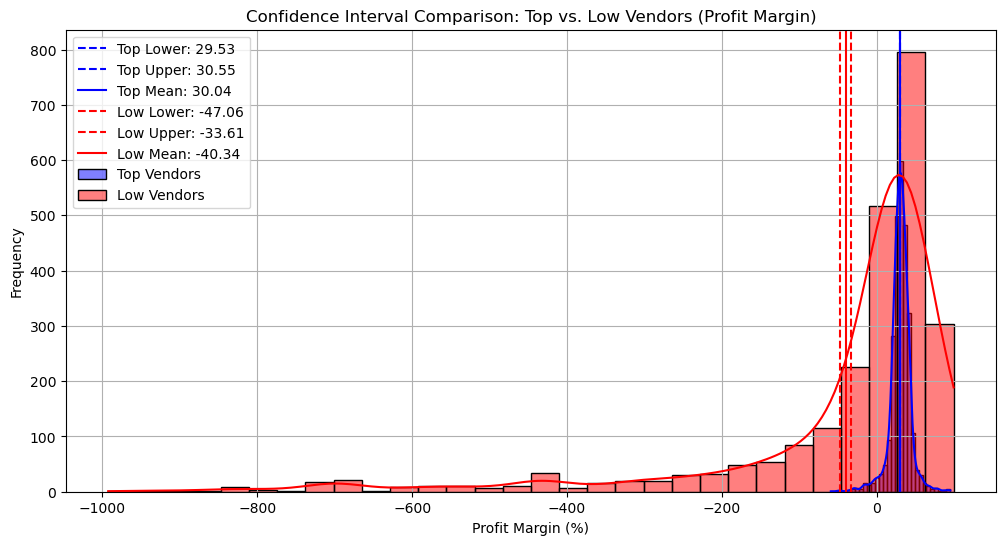

In [88]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)

low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")

print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12,6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")

plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")

plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")

plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")

plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")

plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")

plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")

plt.xlabel("Profit Margin (%)")

plt.ylabel("Frequency")

plt.legend()

plt.grid(True)

plt.show()

In [71]:
import numpy as np

print(np.isinf(low_vendors).sum())

print(np.isnan(low_vendors).sum())

0
0


In [72]:
low_vendors = low_vendors.replace([np.inf, -np.inf], np.nan)

low_vendors = low_vendors.dropna()

top_vendors = top_vendors.replace([np.inf, -np.inf], np.nan)

top_vendors = top_vendors.dropna()


In [73]:
low_vendors = low_vendors[low_vendors > -1000]

In [74]:
print(low_vendors.min())

print(low_vendors.max())

-992.5903245560316
99.16607939863754


In [75]:
print(low_vendors.head())

print(top_vendors.head())

4235   -966.158066
4783   -807.029478
5052   -587.070376
5063   -569.563144
5114   -699.955551
Name: ProfitMargin, dtype: float64
0    25.297693
1    21.062810
2    24.675786
3    27.139908
4    28.412764
Name: ProfitMargin, dtype: float64


In [76]:

def confidence_interval(data):

    mean = data.mean()

    std = data.std()

    n = len(data)

    margin = 1.96 * (std / (n ** 0.5))

    lower = mean - margin

    upper = mean + margin

    return mean, lower, upper

In [77]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)

low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")

print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

Top Vendors 95% CI: (29.53, 30.55), Mean: 30.04
Low Vendors 95% CI: (-47.06, -33.61), Mean: -40.34


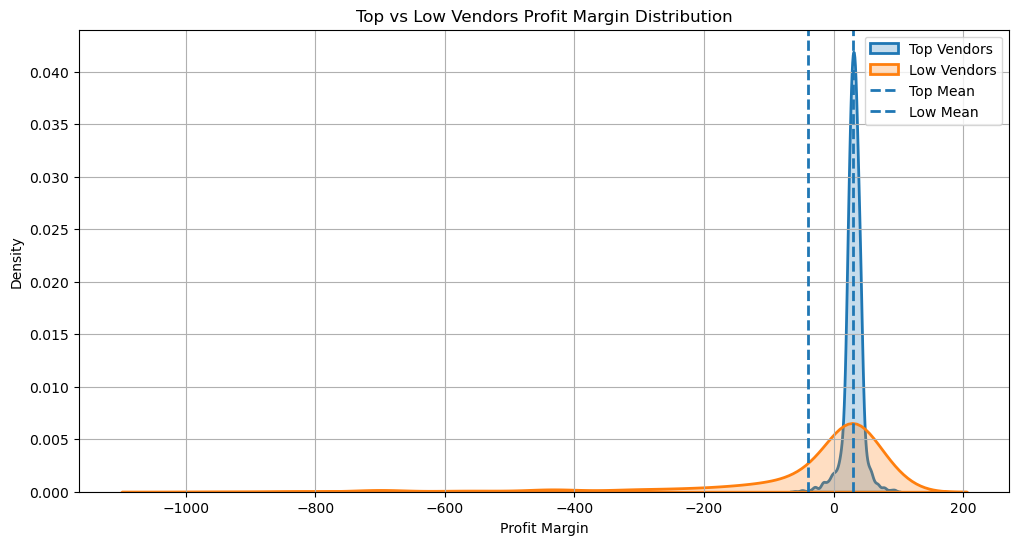

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

# Top Vendors
sns.kdeplot(top_vendors,
            fill=True,
            linewidth=2,
            label='Top Vendors')

# Low Vendors
sns.kdeplot(low_vendors,
            fill=True,
            linewidth=2,
            label='Low Vendors')

# Mean Lines
plt.axvline(top_mean,
            linestyle='--',
            linewidth=2,
            label='Top Mean')

plt.axvline(low_mean,
            linestyle='--',
            linewidth=2,
            label='Low Mean')

# Labels
plt.title("Top vs Low Vendors Profit Margin Distribution")

plt.xlabel("Profit Margin")

plt.ylabel("Density")

plt.legend()

plt.grid(True)

plt.show()

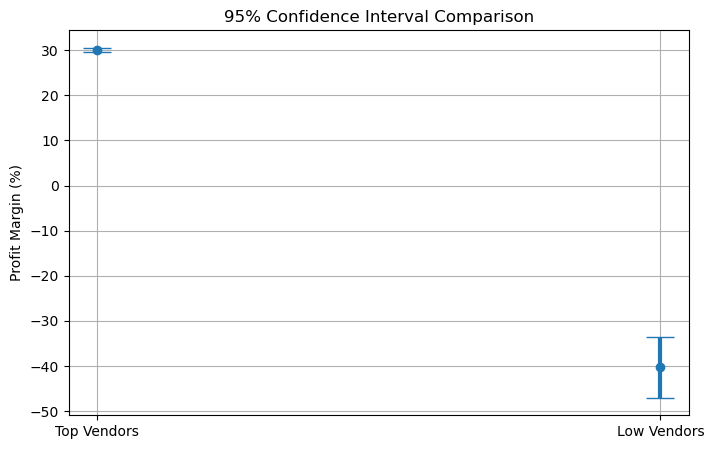

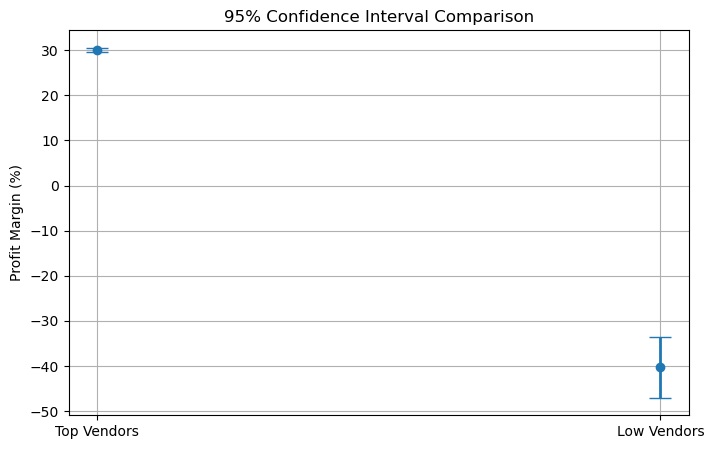

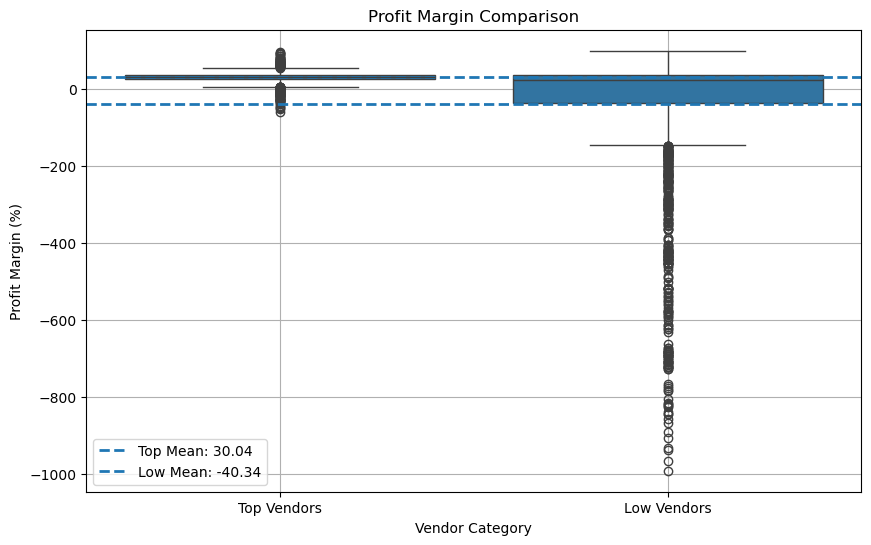

In [89]:
# is there a significant difference in profit margins between top-performing and low - performing vendors

In [96]:
import numpy as np
from scipy.stats import ttest_ind

# Clean ProfitMargin column
df["ProfitMargin"] = df["ProfitMargin"].replace([np.inf, -np.inf], np.nan)

# Remove rows with missing ProfitMargin
clean_df = df.dropna(subset=["ProfitMargin"])

# Thresholds
top_threshold = clean_df["TotalSalesDollars"].quantile(0.75)

low_threshold = clean_df["TotalSalesDollars"].quantile(0.25)

# Top Vendors
top_vendors = clean_df[
    clean_df["TotalSalesDollars"] >= top_threshold
]["ProfitMargin"]

# Low Vendors
low_vendors = clean_df[
    clean_df["TotalSalesDollars"] <= low_threshold
]["ProfitMargin"]

# Optional: remove extreme outliers
low_vendors = low_vendors[low_vendors > -1000]

# T-Test
t_stat, p_value = ttest_ind(
    top_vendors,
    low_vendors,
    equal_var=False
)

# Output
print(f"T-Statistic: {t_stat:.4f}")

print(f"P-Value: {p_value:.4f}")

# Decision
if p_value < 0.05:
    print("Reject H0: Significant difference exists.")
else:
    print("Fail to Reject H0: No significant difference.")

T-Statistic: 20.8329
P-Value: 0.0000
Reject H0: Significant difference exists.


In [97]:
print(top_vendors.isna().sum())

print(low_vendors.isna().sum())

print(np.isinf(top_vendors).sum())

print(np.isinf(low_vendors).sum())

0
0
0
0


In [98]:
df.to_csv("sales_cleaned.csv",index=False)

In [99]:
df.to_csv("end_inventory_cleaned.csv",index=False)

In [100]:
df.to_csv("purchases_cleaned.csv",index=False)

In [101]:
df.to_csv("purchase_prices_cleaned.csv",index=False)

In [102]:
df.to_csv("vendor_invoice_cleaned.csv",index=False)

In [103]:
df.to_csv("begin_inventory_cleaned.csv",index=False)

In [104]:
import os 
os.getcwd()

'C:\\Users\\pranj\\Data'

In [105]:
vendor_sales_summary.column

NameError: name 'vendor_sales_summary' is not defined